# Melton et al., 2025: Hyperparamter sweep analysis - Cell type prediction

Analyse how performance relates to hyperparameters..

**Part 1: Hyperparmeter sweep**

Run hyperparameter sweep with script `hyperparameter.yaml` and config file: 


In [18]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [3]:
import wandb
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: francesca-drummer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs
from InterScale.config import load_config, config_from_wandb_run

/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.10/dist-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.

In [5]:
import yaml
import matplotlib.pyplot as plt
import scanpy as sc

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Hyperparameter sweep

Evaluation of node-classification (Cell type) hyperparameter sweep.

In [6]:
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial', 'Fibroblasts']

### Load WandB IDs

In [7]:
GNN_sweep = "tixesx9b"
Dual_sweep = "d9lf50og"

In [8]:
SWEEP_GOAL = 'hyperparameter'

In [9]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
Dual_wandb = Wandb_evaluation("InterScale", Dual_sweep, True, True, SWEEP_GOAL, CLASSES)

In [59]:
Dual_wandb.get_dataframe().to_csv(f"{BASE_DIR_REPO}//DualInterScale.csv")

In [10]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,test_f1_class_Endothelial,test_f1_class_Fibroblasts,n_embed,lr,wd,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout
0,eo8zf316,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,119.609158,31545,0.152462,...,0.071304,0.037037,16,0.010,0.010,10,16,1,64,0.0
1,8iynilij,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,118.837533,126153,0.384902,...,0.050000,0.132574,64,0.010,0.100,30,32,1,128,0.3
2,jvca3zu7,melton25_clas_node_44_GCN_,44,finished,0.5,110,None,157.203672,31545,0.425476,...,0.091667,0.172169,16,0.001,0.000,10,32,1,128,0.0
3,anmc5420,melton25_clas_node_44_GCN_,44,finished,0.0,110,None,413.558504,31545,0.712727,...,0.514756,0.646103,16,0.001,0.000,20,64,1,512,0.0
4,9j7c4lcv,melton25_clas_node_44_GCN_,44,finished,0.0,110,None,145.181081,31545,0.708634,...,0.525582,0.638774,16,0.010,0.001,10,32,1,512,0.1


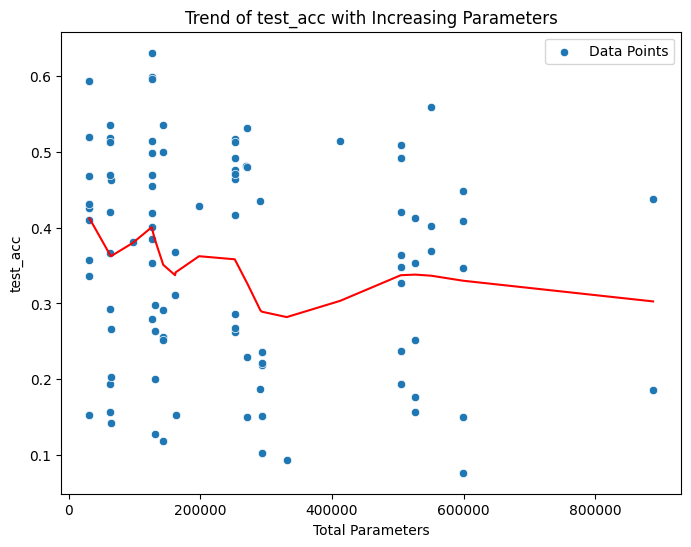

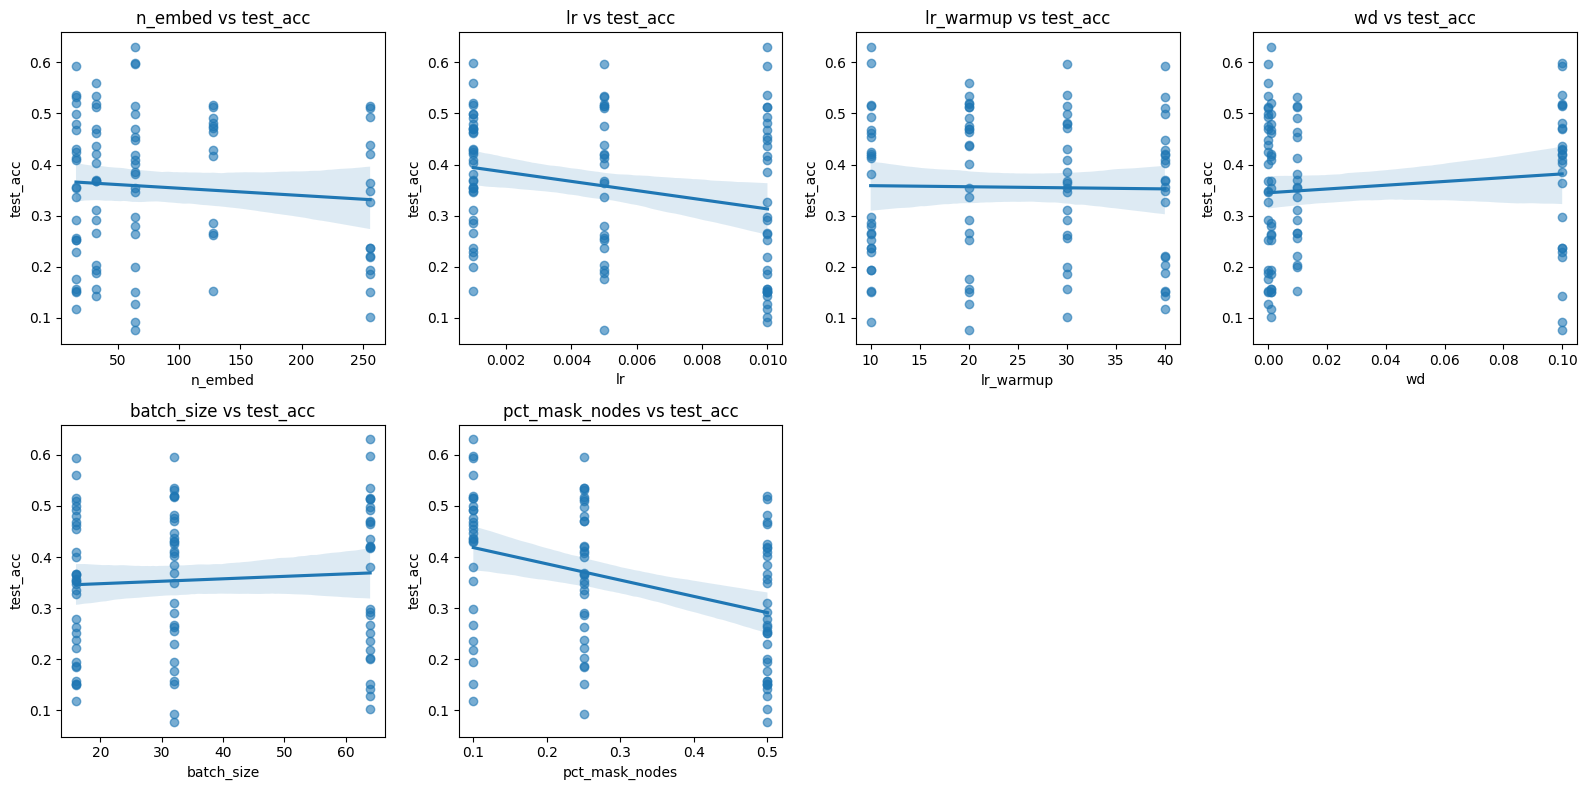

Saved figures to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/figures/melton25/node_class


In [11]:
GNN_wandb.plot_parameter_space(metric = 'test_acc', relevant_params = GNN_wandb.hyperparameters, exclude_parameters = {"pct_mask_nodes":[0.0]}, save_path = f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


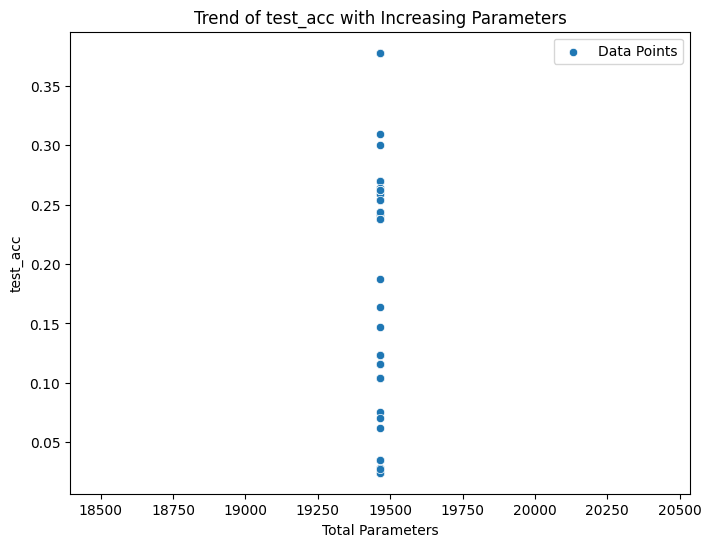

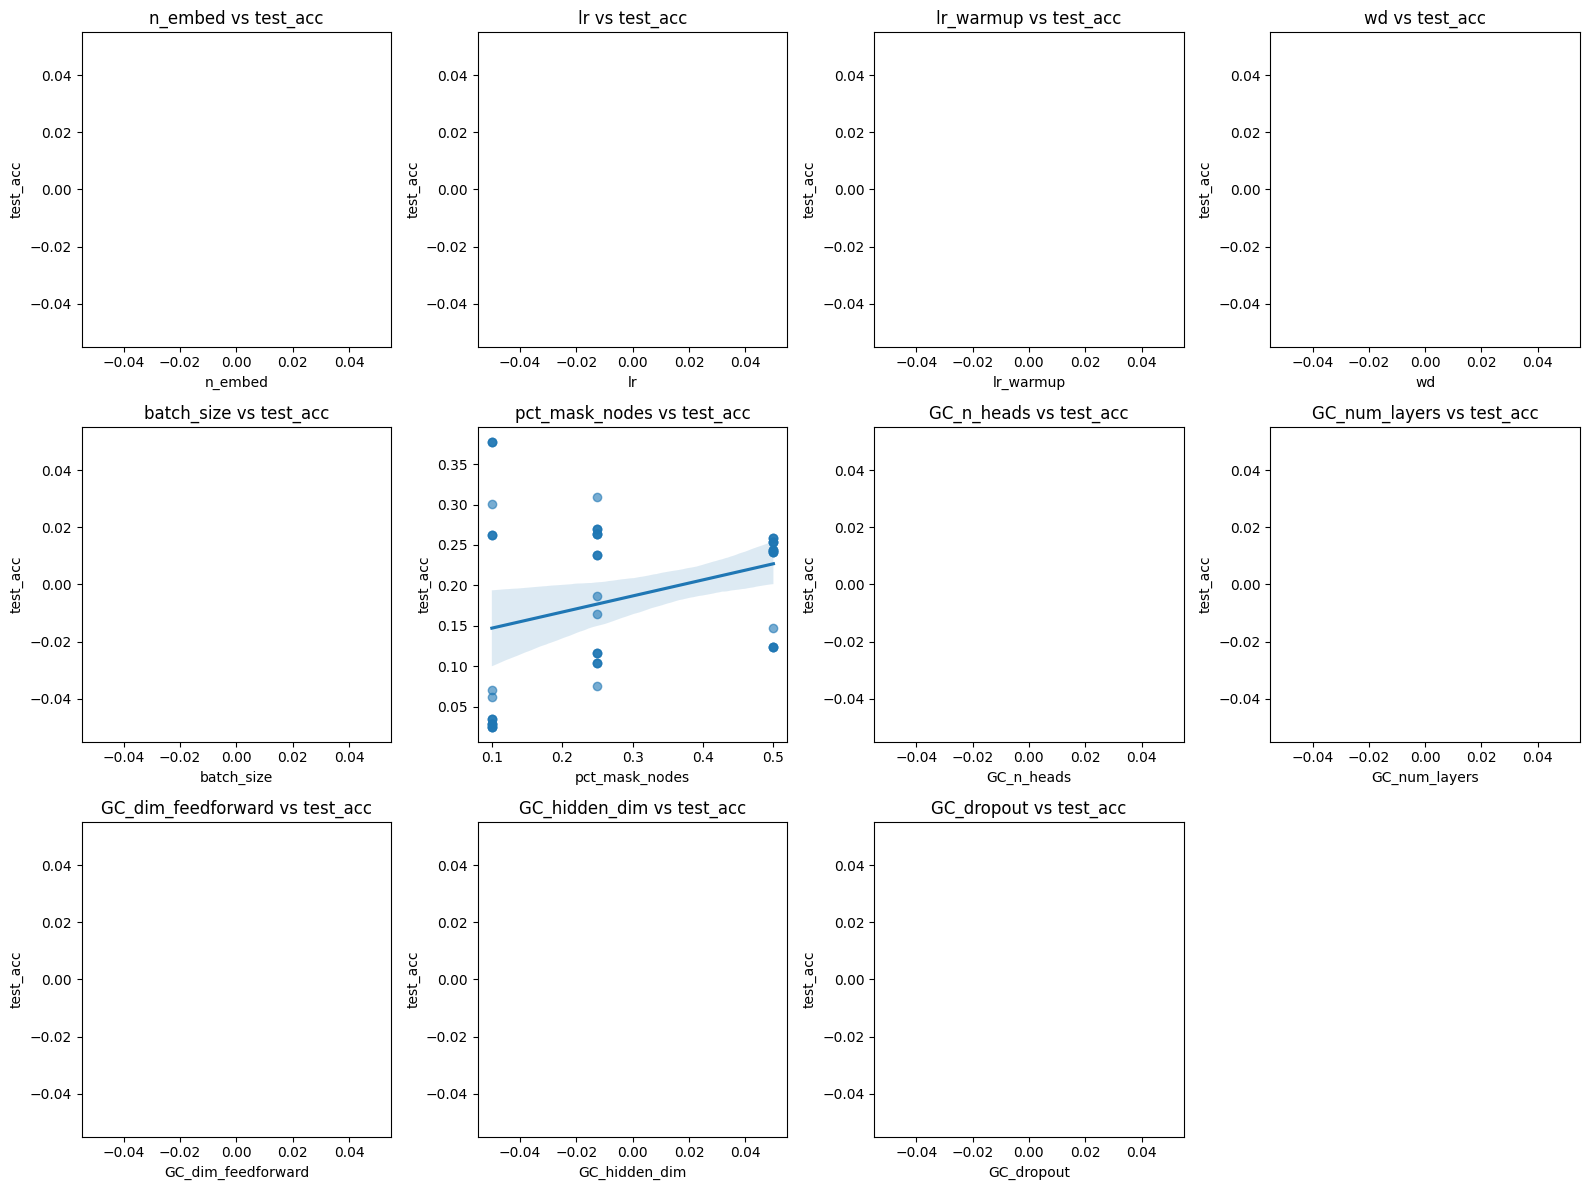

In [13]:
relevant_params = PCATrans_wandb.hyperparameters + PCATrans_wandb.global_component_params
PCATrans_wandb.plot_parameter_space(metric = 'test_acc', relevant_params = relevant_params, exclude_parameters = {"pct_mask_nodes":[0.0]})

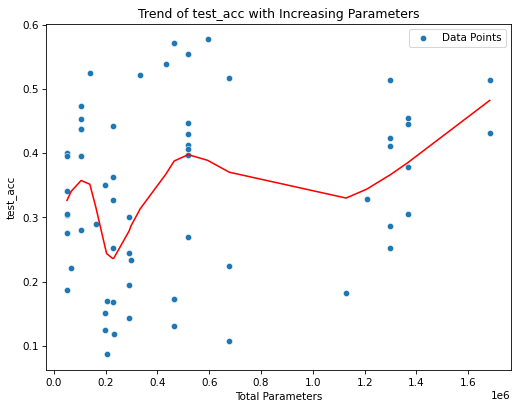

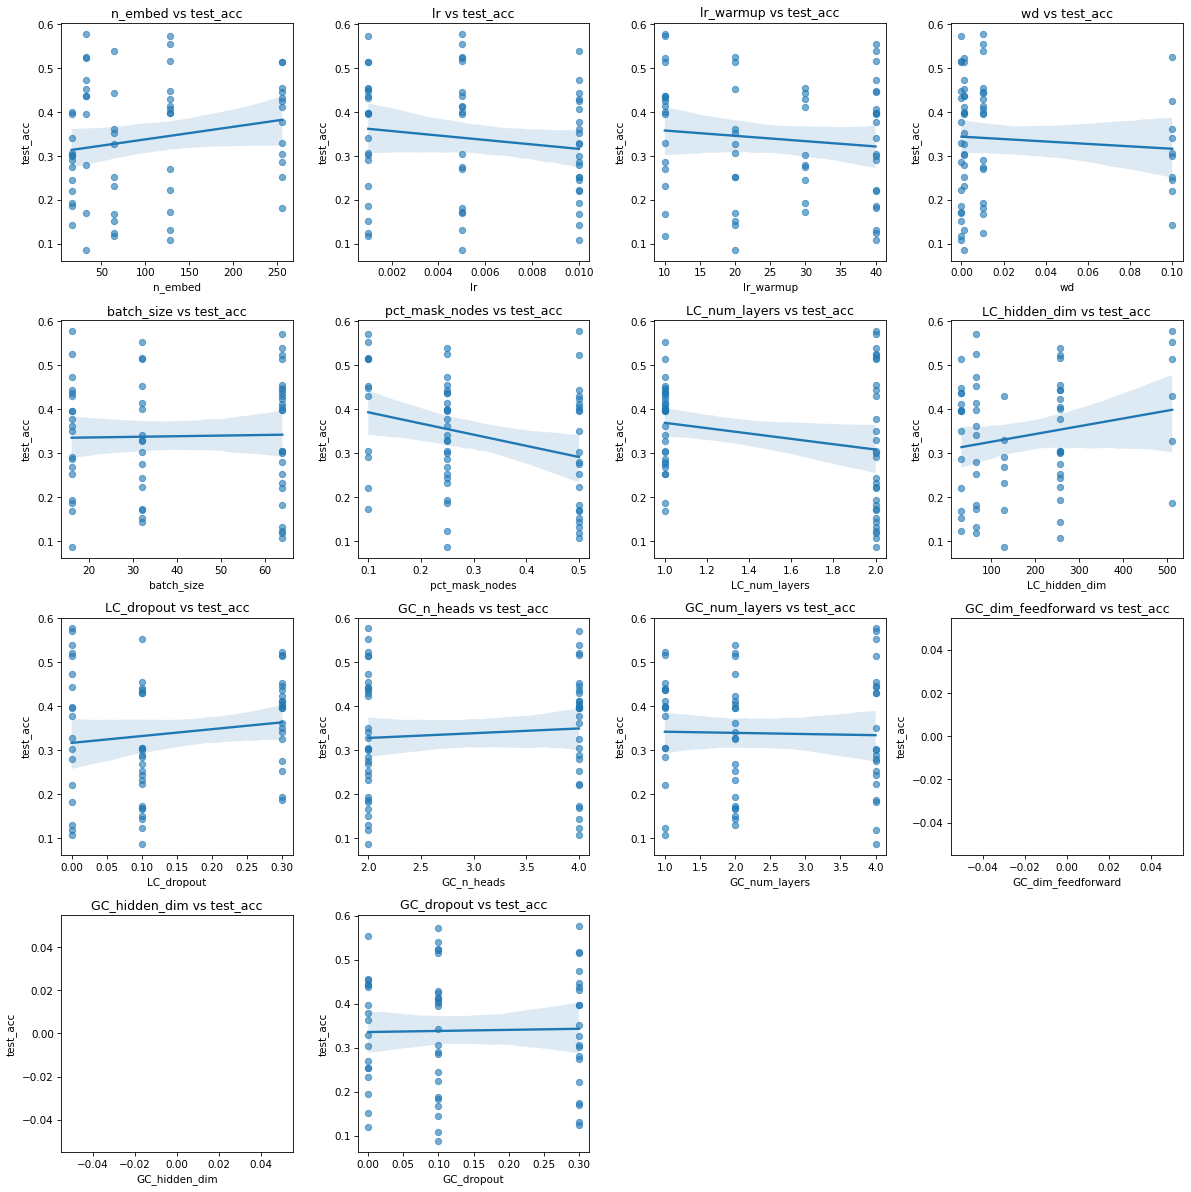

Saved figures to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/figures/melton25/node_class


In [60]:
relevant_params = Dual_wandb.hyperparameters + Dual_wandb.local_component_params + Dual_wandb.global_component_params
Dual_wandb.plot_parameter_space(metric = 'test_acc', relevant_params = relevant_params, exclude_parameters = {"pct_mask_nodes":[0.0]}, save_path = f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

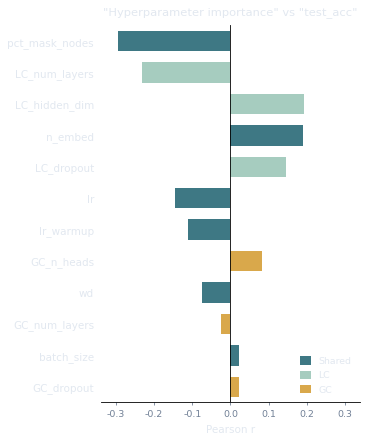

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


def plot_param_importance(
    df: pd.DataFrame,
    metric: str = "test_acc",
    lc_params: list[str] | None = None,
    gc_params: list[str] | None = None,
    shared_params: list[str] | None = None,
    exclude_params: list[str] | None = None,
    figsize: tuple = (5, 6),
    title: str | None = None,
    lc_color: str = "#A6CCBF",
    gc_color: str = "#D9A84B",
    shared_color: str = "#3E7884",
    top_n: int | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot hyperparameter importance as a horizontal bar chart in scanpy style,
    coloured by parameter group (LC / GC / SHARED), sorted by absolute
    correlation (highest at top).
 
    Parameters
    ----------
    df : pd.DataFrame
        Sweep results dataframe. Must contain `metric` and all HP columns.
    metric : str
        Column to correlate HPs against. Default 'test_acc'.
    lc_params : list[str] | None
        Local-component HP column names. Auto-detected (prefix 'LC_') if None.
    gc_params : list[str] | None
        Global-component HP column names. Auto-detected (prefix 'GC_') if None.
    shared_params : list[str] | None
        Shared HP column names. Auto-detected (everything else) if None.
    exclude_params : list[str] | None
        Columns to drop before computing correlations (e.g. fully-NaN cols).
    figsize : tuple
        Figure size passed to plt.subplots.
    title : str | None
        Plot title wrapped in double quotes, scanpy-style. Defaults to
        '"Hyperparameter importance" vs "{metric}"'.
    lc_color : str
        Bar colour for LC parameters. Default '#A6CCBF'.
    gc_color : str
        Bar colour for GC parameters. Default '#D9A84B'.
    shared_color : str
        Bar colour for shared parameters. Default '#E8857A'.
    top_n : int | None
        If set, show only the top N parameters by absolute correlation.
 
    Returns
    -------
    fig, ax : matplotlib Figure and Axes objects.
 
    Example
    -------
    >>> import pandas as pd
    >>> from plot_param_importance import plot_param_importance
    >>> df = pd.read_csv("DualInterScale.csv", index_col=0)
    >>> df = df[df["pct_mask_nodes"] != 0.0]
    >>> fig, ax = plot_param_importance(df, metric="test_acc")
    >>> fig.savefig("importance.png", dpi=150, bbox_inches="tight")
    """
 
    # ── Detect HP columns ─────────────────────────────────────────────────────
    non_hp_cols = {
        "id", "name", "seed", "state", "runtime_seconds", "total_parameters",
        "decoder_type", "radius",
        metric,
        *[c for c in df.columns if c.startswith("test_f1")],
    }
    if exclude_params:
        non_hp_cols.update(exclude_params)
 
    candidate_cols = [c for c in df.columns if c not in non_hp_cols]
 
    if lc_params is None:
        lc_params = [c for c in candidate_cols if c.startswith("LC_")]
    if gc_params is None:
        gc_params = [c for c in candidate_cols if c.startswith("GC_")]
    if shared_params is None:
        shared_params = [
            c for c in candidate_cols
            if c not in lc_params and c not in gc_params
        ]
 
    all_params = shared_params + lc_params + gc_params
 
    # ── Compute Pearson r ─────────────────────────────────────────────────────
    correlations = {}
    for hp in all_params:
        sub = df[[hp, metric]].dropna()
        if sub[hp].nunique() < 2 or len(sub) < 5:
            continue
        r = sub[hp].corr(sub[metric])
        if not np.isnan(r):
            correlations[hp] = r
 
    if not correlations:
        raise ValueError("No valid correlations could be computed.")
 
    # Sort descending by |r|; top_n slice; then reverse for barh (top = highest)
    corr_s = pd.Series(correlations).sort_values(key=abs, ascending=False)
    if top_n is not None:
        corr_s = corr_s.iloc[:top_n]
    corr_s = corr_s.iloc[::-1]   # reverse so highest ends up at the top of the plot
 
    # ── Helpers ───────────────────────────────────────────────────────────────
    def group_color(hp):
        if hp in lc_params:   return lc_color
        if hp in gc_params:   return gc_color
        return shared_color
 
    def group_label(hp):
        if hp in lc_params:   return "LC"
        if hp in gc_params:   return "GC"
        return "Shared"
 
    # ── Style (clean matplotlib / scanpy look) ────────────────────────────────
    plt.rcParams.update({
        "font.family":      "sans-serif",
        "font.size":        10,
        "axes.facecolor":   "white",
        "figure.facecolor": "white",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.spines.left":   True,
        "axes.spines.bottom": True,
        "xtick.bottom":     True,
        "ytick.left":       True,
        "axes.grid":        False,
    })
 
    fig, ax = plt.subplots(figsize=figsize)
 
    n = len(corr_s)
    y_pos = np.arange(n)
    bar_height = 0.65
 
    # ── Bars ──────────────────────────────────────────────────────────────────
    colors = [group_color(hp) for hp in corr_s.index]
    ax.barh(y_pos, corr_s.values, height=bar_height, color=colors, linewidth=0)
 
    # ── Zero line ─────────────────────────────────────────────────────────────
    ax.axvline(0, color="black", linewidth=0.8, zorder=3)
 
    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(corr_s.index, fontsize=10)
    ax.set_ylim(-0.5, n - 0.5)
 
    x_max = corr_s.abs().max()
    ax.set_xlim(-x_max * 1.15, x_max * 1.15)
    ax.set_xlabel("Pearson r", fontsize=10, labelpad=6)
 
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", which="both", length=3, width=0.8)
    ax.tick_params(axis="y", which="both", left=False)
 
    # X ticks symmetric around 0
    tick_step = 0.1 if x_max <= 0.5 else 0.2
    x_ticks = np.concatenate([
        np.arange(0, -x_max * 1.1, -tick_step)[::-1],
        np.arange(tick_step, x_max * 1.1, tick_step),
    ])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{v:.1f}" for v in x_ticks], fontsize=9)
 
    # ── Title (scanpy style: quoted group name) ───────────────────────────────
    if title is None:
        title = f'"Hyperparameter importance" vs "{metric}"'
    ax.set_title(title, fontsize=11, pad=10)
 
    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=shared_color, label="Shared"),
        mpatches.Patch(facecolor=lc_color,     label="LC"),
        mpatches.Patch(facecolor=gc_color,      label="GC"),
    ]
    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=9,
        loc="lower right",
        handlelength=1.2,
        handleheight=1.0,
    )
 
    fig.tight_layout()
    return fig, ax
 
 
# ── Quick demo ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = pd.read_csv("DualInterScale.csv", index_col=0)
    df = df.drop(columns=["GC_hidden_dim", "GC_dim_feedforward"], errors="ignore")
    df = df[df["pct_mask_nodes"] != 0.0]
 
    fig, ax = plot_param_importance(df, metric="test_acc")
    fig.savefig(f"{BASE_DIR_REPO}/importance.png", dpi=150, bbox_inches="tight")
    plt.show()

### Best model selection

In [26]:
df = Dual_wandb.filter_runs(exclude_parameters = {"pct_mask_nodes":[0.0]})
df.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
0,sysappn2,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.50,110,None,205.602434,197842,0.151653,...,20,32,2,32,0.1,2,2,None,None,0.0
1,4um0v8yu,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,160.353546,464786,0.173032,...,30,32,2,64,0.1,4,2,None,None,0.3
2,g2mx3fkm,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,182.710215,105586,0.436869,...,10,16,1,32,0.3,4,1,None,None,0.0
3,w7knxdm4,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,149.468218,204050,0.086806,...,20,16,2,128,0.1,2,4,None,None,0.1
4,3gai2tif,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,193.831205,1682962,0.514339,...,10,32,2,512,0.3,2,4,None,None,0.3


In [ ]:
df

In [30]:
df[df['test_acc'] > 0.55]

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
9,jaokfets,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,169.764292,519058,0.553819,...,40,32,1,512,0.1,2,4,None,None,0.0
43,7gfchrbo,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,181.978601,464786,0.571875,...,10,64,2,64,0.0,4,4,None,None,0.1
52,iigu25p9,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.5,110,None,169.006287,593426,0.577257,...,10,16,2,512,0.0,2,4,None,None,0.3


In [14]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data/melton25.h5ad"))

In [13]:
Dual_wandb.export_config_to_yaml(best_run_id="jaokfets", save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/best_config.yaml")

Config saved to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml


'/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml'

### Load WandB IDs

In [23]:
GNN_sweep = "l0jetvrz"
InterScale_sweep = "yqvyut7l"
DualInterScale_sweep = "1nm8ndul"
PCATrans_sweep = "8govw06t"

In [43]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial', 'Fibroblasts']

Q: Why does PCATrans not have test_f1 scores?

In [44]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, False, True, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, True, True, SWEEP_GOAL, CLASSES)
DualInterScale_wandb = Wandb_evaluation("DualInterScale", DualInterScale_sweep, True, True, SWEEP_GOAL, CLASSES)

In [26]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro,test_f1_macro,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,nc6wcxh4,melton25_clas_node_44_GCN_,44,finished,0.5,150,None,583.736024,255145,0.410172,0.410172,0.253926,0.074074,0.577701,0.187302,0.483192,0.000000,0.219942,0.0,0.120466
1,n72wxcou,melton25_clas_node_44_GCN_,43,finished,0.5,150,None,610.241567,255145,0.345615,0.345615,0.202811,0.074074,0.741093,0.150794,0.000000,0.222222,0.160729,0.0,0.000000
2,qrvo7c6z,melton25_clas_node_44_GCN_,42,finished,0.5,150,None,623.258038,255145,0.229102,0.229102,0.161782,0.211111,0.552431,0.111111,0.012950,0.111111,0.143627,0.0,0.020202
3,ltgzyu44,melton25_clas_node_44_GCN_,41,finished,0.5,150,None,587.714794,255145,0.158501,0.158501,0.126449,0.111111,0.392892,0.055556,0.008230,0.055556,0.165252,0.0,0.055931
4,o6zttv7w,melton25_clas_node_44_GCN_,40,finished,0.5,150,None,594.628172,255145,0.357124,0.357124,0.208204,0.111111,0.492742,0.211111,0.474357,0.111111,0.191293,0.0,0.029440


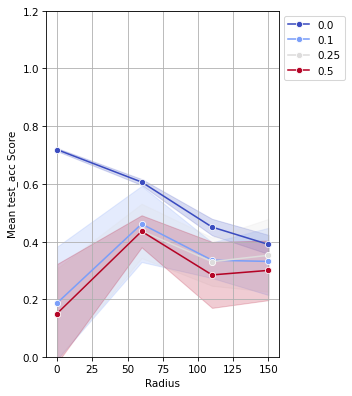

In [30]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

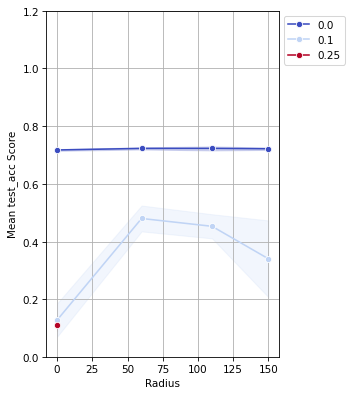

In [32]:
DualInterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

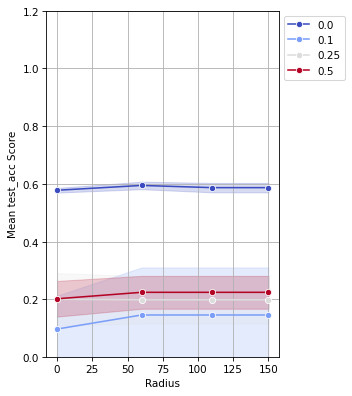

In [34]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

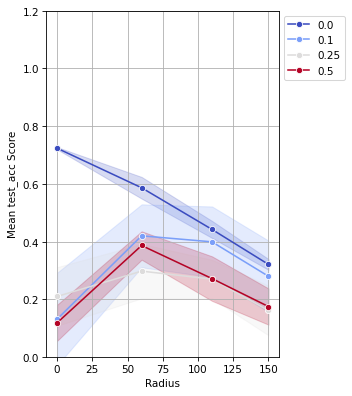

In [35]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/figures/{DATA}/node_class")

In [45]:
wandb_evals = [GNN_wandb, PCATrans_wandb, DualInterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

             model                      class      mean       std  n_seeds
0   DualInterScale       test_f1_class_Acinar  0.753935  0.005037        5
1   DualInterScale        test_f1_class_Alpha  0.674761  0.008327        5
2   DualInterScale         test_f1_class_Beta  0.587428  0.008500        5
3   DualInterScale       test_f1_class_Ductal  0.767753  0.008048        5
4   DualInterScale    test_f1_class_Endocrine  0.600121  0.062506        5
5   DualInterScale  test_f1_class_Endothelial  0.540104  0.016871        5
6   DualInterScale  test_f1_class_Fibroblasts  0.639623  0.009480        5
7   DualInterScale       test_f1_class_Immune  0.602552  0.009768        5
8   DualInterScale         test_f1_class_Mast  0.332355  0.017566        5
9              GCN       test_f1_class_Acinar  0.727350  0.006129        5
10             GCN        test_f1_class_Alpha  0.613468  0.008930        5
11             GCN         test_f1_class_Beta  0.501538  0.016221        5
12             GCN       

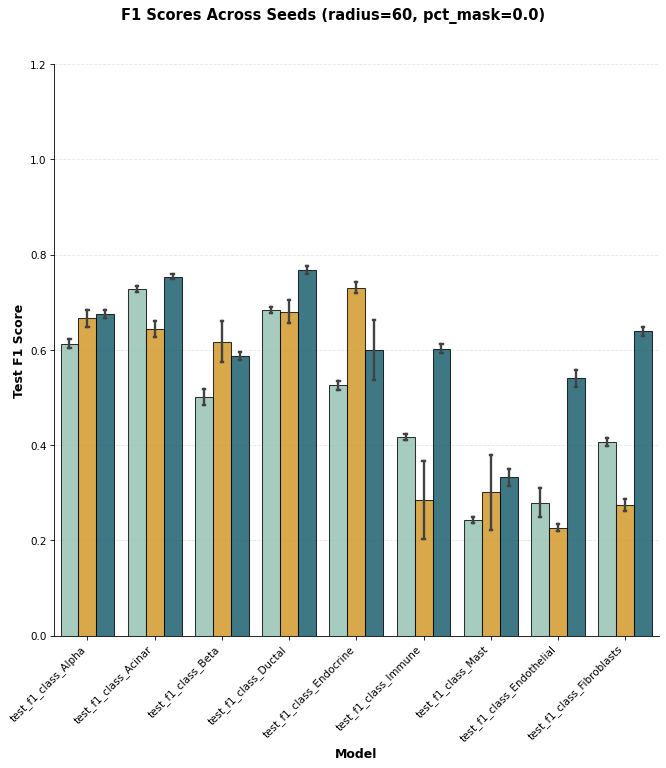

In [50]:
g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=60,
    pct_mask_nodes=0.0,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/node_class/f1_comparison_models_radius'
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

In [52]:
from src.wandb import plot_class_f1_robustness

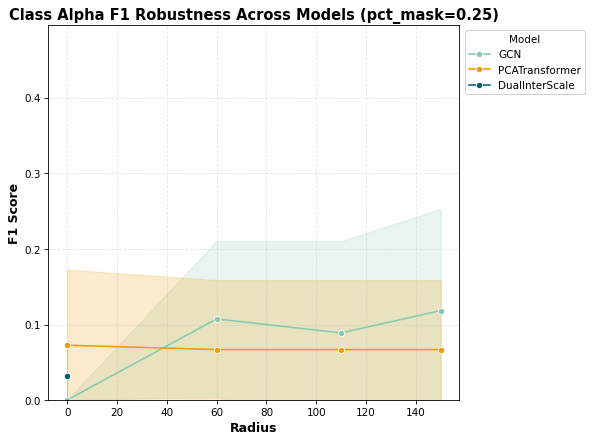


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.032407 0.038177        4
           GCN       0 0.000000 0.000000        5
           GCN      60 0.107407 0.103439        5
           GCN     110 0.088889 0.121716        5
           GCN     150 0.118519 0.134562        5
PCATransformer       0 0.072581 0.100241        5
PCATransformer      60 0.066843 0.091974        5
PCATransformer     110 0.066843 0.091974        5
PCATransformer     150 0.066843 0.091974        5


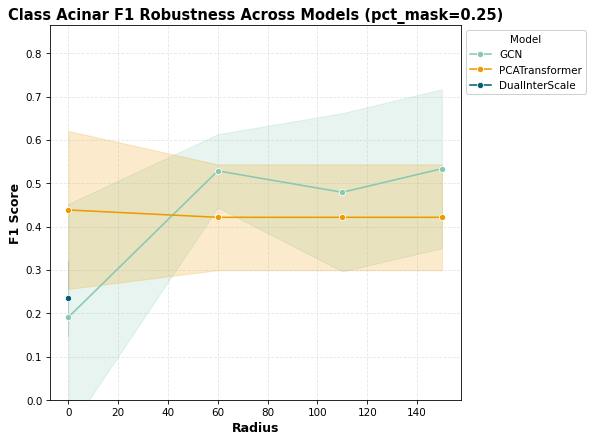


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.236112 0.087405        4
           GCN       0 0.190983 0.261579        5
           GCN      60 0.528654 0.084491        5
           GCN     110 0.479281 0.182541        5
           GCN     150 0.533686 0.183318        5
PCATransformer       0 0.438530 0.182190        5
PCATransformer      60 0.421540 0.121940        5
PCATransformer     110 0.421540 0.121940        5
PCATransformer     150 0.421540 0.121940        5


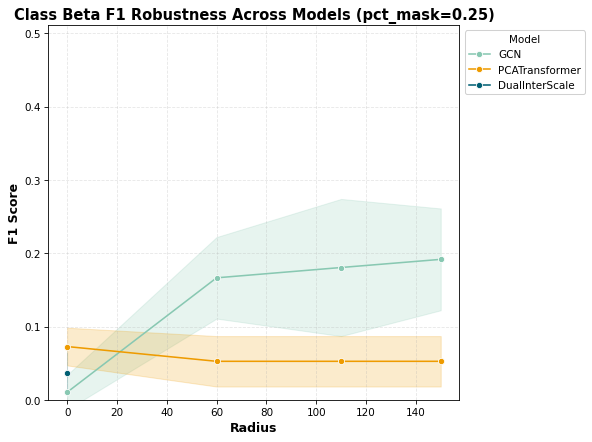


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.036922 0.028581        4
           GCN       0 0.010616 0.023738        5
           GCN      60 0.166667 0.055556        5
           GCN     110 0.180741 0.093492        5
           GCN     150 0.191852 0.069409        5
PCATransformer       0 0.072953 0.025717        5
PCATransformer      60 0.052822 0.034392        5
PCATransformer     110 0.052822 0.034392        5
PCATransformer     150 0.052822 0.034392        5


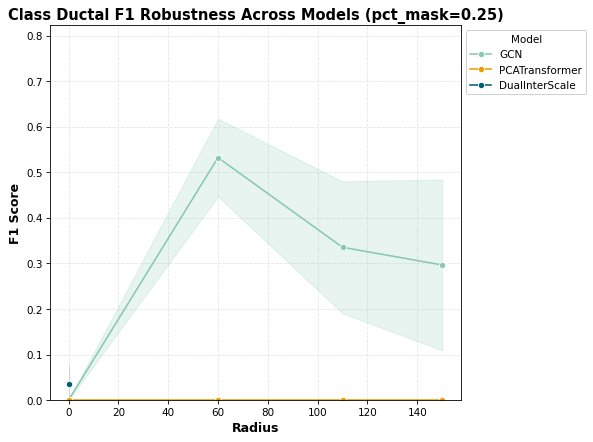


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.034526 0.042426        4
           GCN       0 0.000000 0.000000        5
           GCN      60 0.532613 0.085451        5
           GCN     110 0.335554 0.144889        5
           GCN     150 0.296806 0.187825        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


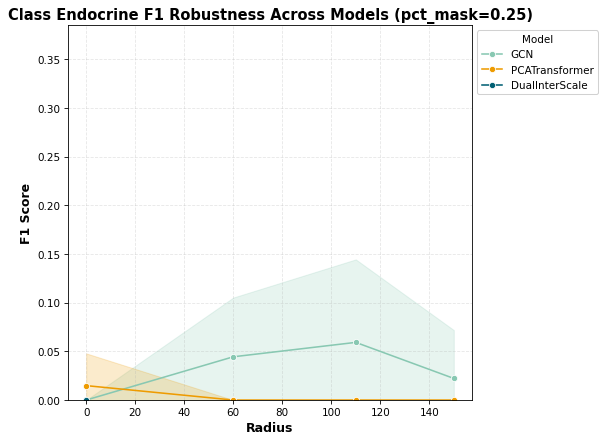


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.000000 0.000000        4
           GCN       0 0.000000 0.000000        5
           GCN      60 0.044444 0.060858        5
           GCN     110 0.059259 0.085266        5
           GCN     150 0.022222 0.049690        5
PCATransformer       0 0.014815 0.033127        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


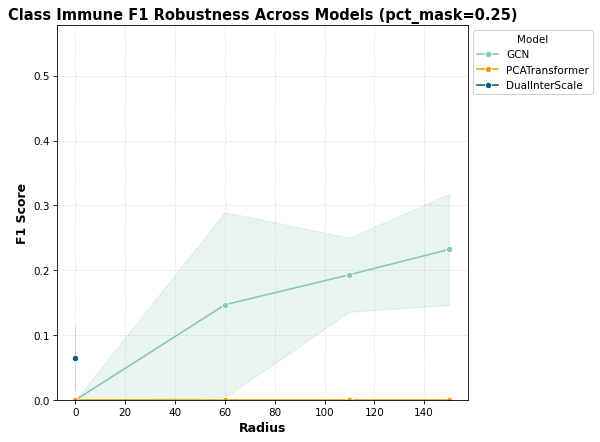


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.064574 0.048816        4
           GCN       0 0.000000 0.000000        5
           GCN      60 0.146862 0.142870        5
           GCN     110 0.193160 0.057057        5
           GCN     150 0.232162 0.085587        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


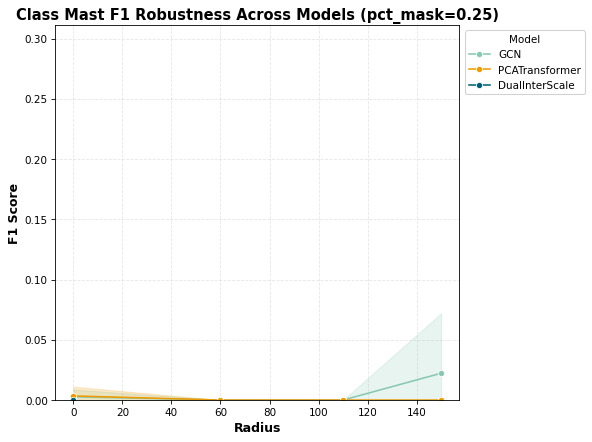


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.000000 0.000000        4
           GCN       0 0.002694 0.006023        5
           GCN      60 0.000000 0.000000        5
           GCN     110 0.000000 0.000000        5
           GCN     150 0.022222 0.049690        5
PCATransformer       0 0.003419 0.007645        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


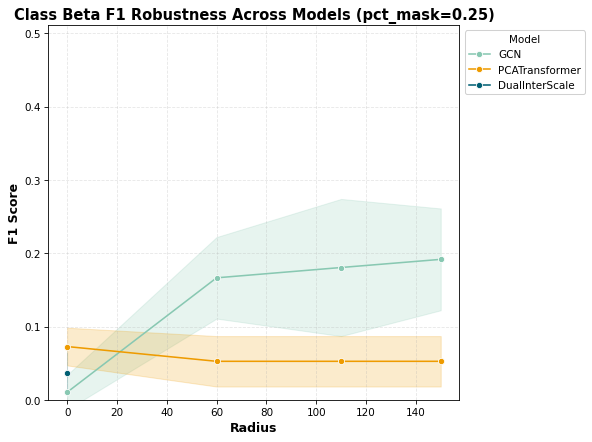


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.036922 0.028581        4
           GCN       0 0.010616 0.023738        5
           GCN      60 0.166667 0.055556        5
           GCN     110 0.180741 0.093492        5
           GCN     150 0.191852 0.069409        5
PCATransformer       0 0.072953 0.025717        5
PCATransformer      60 0.052822 0.034392        5
PCATransformer     110 0.052822 0.034392        5
PCATransformer     150 0.052822 0.034392        5


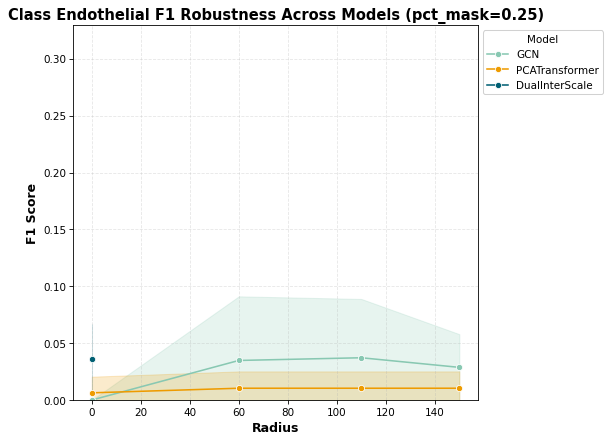


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.036498 0.030317        4
           GCN       0 0.000000 0.000000        5
           GCN      60 0.034815 0.056389        5
           GCN     110 0.037197 0.051702        5
           GCN     150 0.028740 0.029201        5
PCATransformer       0 0.006349 0.014197        5
PCATransformer      60 0.010390 0.014800        5
PCATransformer     110 0.010390 0.014800        5
PCATransformer     150 0.010390 0.014800        5


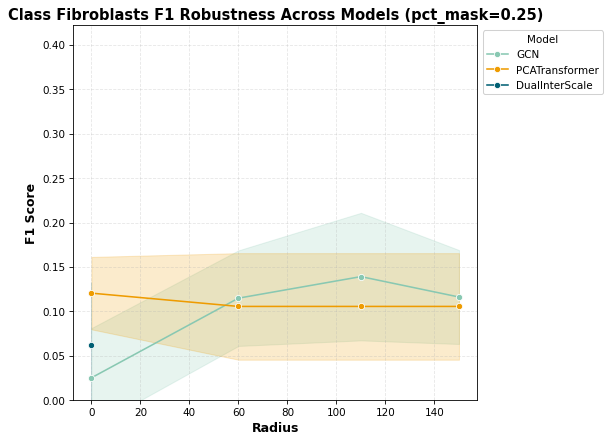


Statistics Summary:
         model  radius     mean      std  n_seeds
DualInterScale       0 0.061950 0.071382        4
           GCN       0 0.025034 0.055977        5
           GCN      60 0.114775 0.053832        5
           GCN     110 0.139051 0.071834        5
           GCN     150 0.116074 0.052927        5
PCATransformer       0 0.120432 0.040776        5
PCATransformer      60 0.105462 0.060022        5
PCATransformer     110 0.105462 0.060022        5
PCATransformer     150 0.105462 0.060022        5


In [56]:
for class_id in CLASSES: 
    fig, ax, stats = plot_class_f1_robustness(
        wandb_evals,
        class_idx=class_id,
        pct_mask_nodes=0.25,
        BASE_DIR_REPO=BASE_DIR_REPO, 
        #save_path=f"{BASE_DIR_REPO}/figures/{DATA}/node_class"
    )